# End to End Analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler, Normalizer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
file_path = "/content/drive/MyDrive/household_power_consumption.csv"  # Update to actual path
try:
    df = pd.read_csv(file_path, encoding='latin1')  # Use 'latin1' for UTF-8 issues
    print("Original Data:\n", df.head())
except FileNotFoundError:
    print(f"Error: File '{file_path}' not found. Please check the file path.")
    exit(1)
except pd.errors.EmptyDataError:
    print(f"Error: File '{file_path}' is empty or invalid.")
    exit(1)
except Exception as e:
    print(f"Error reading CSV file: {e}")
    exit(1)

# Rename a single column
df.rename(columns={'ï»¿Date': 'Date'}, inplace=True)

Original Data:
       ï»¿Date      Time Global_active_power Global_reactive_power Voltage  \
0  16-12-2006  17:24:00               4.216                 0.418  234.84   
1  16-12-2006  17:25:00                5.36                 0.436  233.63   
2  16-12-2006  17:26:00               5.374                 0.498  233.29   
3  16-12-2006  17:27:00               5.388                 0.502  233.74   
4  16-12-2006  17:28:00               3.666                 0.528  235.68   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0             18.4              0              1        17.00000  
1               23              0              1        16.00000  
2               23              0              2        17.00000  
3               23              0              1        17.00000  
4             15.8              0              1        17.00000  


In [ ]:
df.shape      # Number of rows and columns
df.info()       # Data types and missing values
df.describe()   # Basic statistics
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  object 
 1   Time                   1048575 non-null  object 
 2   Global_active_power    1048575 non-null  object 
 3   Global_reactive_power  1048575 non-null  object 
 4   Voltage                1048575 non-null  object 
 5   Global_intensity       1048575 non-null  object 
 6   Sub_metering_1         1048575 non-null  object 
 7   Sub_metering_2         1048575 non-null  object 
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(1), object(8)
memory usage: 72.0+ MB


,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,4069


In [ ]:
# Convert Date and Time to datetime
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d-%m-%Y %H:%M:%S')

# Drop original Date and Time columns
df.drop(['Date', 'Time'], axis=1, inplace=True)

# Set datetime as index
df.set_index('Datetime', inplace=True)



In [ ]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0,1,17.00000
2006-12-16 17:25:00,5.36,0.436,233.63,23,0,1,16.00000
2006-12-16 17:26:00,5.374,0.498,233.29,23,0,2,17.00000
2006-12-16 17:27:00,5.388,0.502,233.74,23,0,1,17.00000
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0,1,17.00000


In [ ]:
#------- FEATURE ENGINEERING --------
# Extract features from datetime
df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month
df['weekday'] = df.index.weekday
df['year'] = df.index.year

# Optional: create lag features to capture energy usage trends
df['lag_1'] = df['Global_active_power'].shift(1)
df['lag_2'] = df['Global_active_power'].shift(2)
df.dropna(inplace=True)

# Handling Missing Values

In [ ]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Convert columns to numeric
cols = ['Global_active_power','Global_reactive_power','Voltage',
        'Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']

for col in cols:
    df[col] = df[col].astype(float)

# Drop rows with missing values
df.dropna(inplace=True)


In [ ]:
df.isnull().sum()

,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0
hour,0
day,0
month,0


In [ ]:
pd.set_option('display.float_format', '{:.5f}'.format)
df.mean(numeric_only=True).round(5)

,0
Global_active_power,1.10813
Global_reactive_power,0.11827
Voltage,239.95995
Global_intensity,4.71781
Sub_metering_1,1.17739
Sub_metering_2,1.47489
Sub_metering_3,5.93362
hour,11.50427
day,15.69592
month,6.50683


In [ ]:
df.median(numeric_only=True).round(10)

,0
Global_active_power,0.55000
Global_reactive_power,0.09800
Voltage,240.21000
Global_intensity,2.40000
Sub_metering_1,0.00000
Sub_metering_2,0.00000
Sub_metering_3,0.00000
hour,12.00000
day,16.00000
month,7.00000


In [ ]:
(df.isnull().sum() / len(df)) * 100

,0
Global_active_power,0.00000
Global_reactive_power,0.00000
Voltage,0.00000
Global_intensity,0.00000
Sub_metering_1,0.00000
Sub_metering_2,0.00000
Sub_metering_3,0.00000
hour,0.00000
day,0.00000
month,0.00000


In [ ]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day,month,weekday,year
count,1044427.00000,1044427.00000,1044427.00000,1044427.00000,1044427.00000,1044427.00000,1044427.00000,1044427.00000,1044427.00000,1044427.00000,1044427.00000,1044427.00000
mean,1.10813,0.11827,239.95995,4.71781,1.17739,1.47489,5.93362,11.50427,15.69592,6.50683,2.99562,2007.45846
std,1.12947,0.10950,3.28445,4.76325,6.32104,6.35214,8.21035,6.92358,8.80201,3.44226,1.99712,0.53887
min,0.07600,0.00000,223.49000,0.20000,0.00000,0.00000,0.00000,0.00000,1.00000,1.00000,0.00000,2006.00000
25%,0.28800,0.00000,237.97000,1.20000,0.00000,0.00000,0.00000,6.00000,8.00000,4.00000,1.00000,2007.00000
50%,0.55000,0.09800,240.21000,2.40000,0.00000,0.00000,0.00000,12.00000,16.00000,7.00000,3.00000,2007.00000
75%,1.54400,0.18600,242.14000,6.40000,0.00000,1.00000,17.00000,18.00000,23.00000,9.00000,5.00000,2008.00000
max,10.67000,1.39000,252.14000,46.40000,80.00000,78.00000,31.00000,23.00000,31.00000,12.00000,6.00000,2008.00000


# Finding Duplicates

In [ ]:
df.duplicated()

,0
Datetime,
2006-12-16 17:26:00,False
2006-12-16 17:27:00,False
2006-12-16 17:28:00,False
2006-12-16 17:29:00,False
2006-12-16 17:30:00,False
...,...
2008-12-13 21:34:00,False
2008-12-13 21:35:00,False
2008-12-13 21:36:00,False


In [ ]:
df.duplicated().sum()

np.int64(2382)

In [ ]:
df = df.drop_duplicates()

# Data Visualization

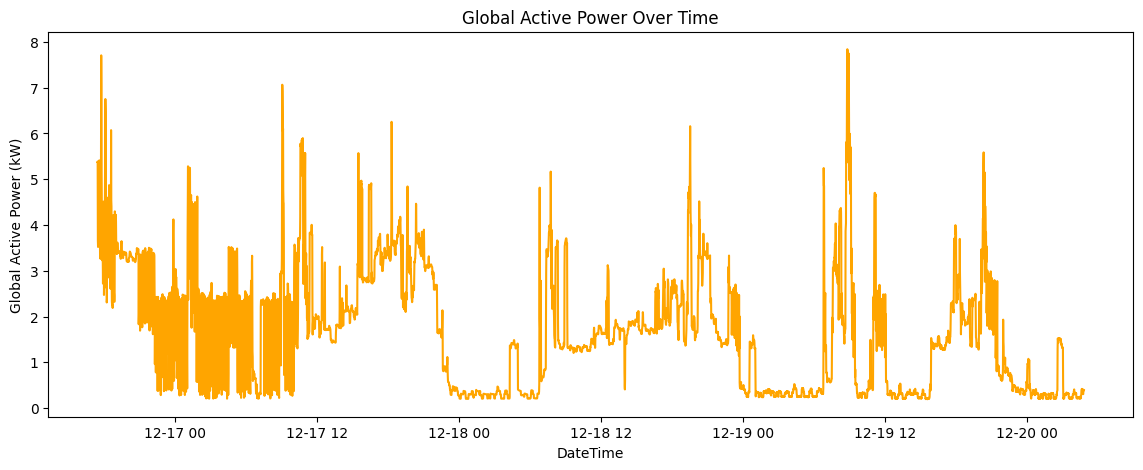

In [ ]:
plt.figure(figsize=(14,5))
selected_df=df.iloc[0:5001]
sns.lineplot(data=selected_df, x='Datetime', y='Global_active_power', color= 'orange')
plt.title('Global Active Power Over Time')
plt.xlabel('DateTime')
plt.ylabel('Global Active Power (kW)')
plt.show()

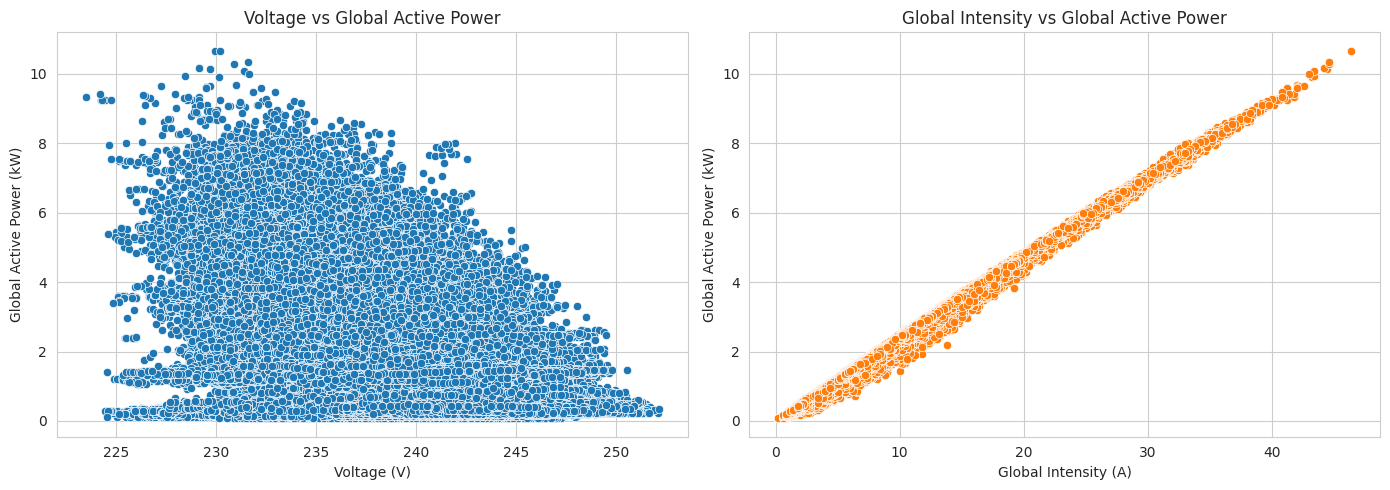

In [ ]:
sns.set_palette("viridis")
sns.set_style("whitegrid")

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Voltage vs Global_active_power
sns.scatterplot(data=df, x='Voltage', y='Global_active_power', ax=axes[0], color='#1f77b4')
axes[0].set_title('Voltage vs Global Active Power')
axes[0].set_xlabel('Voltage (V)')
axes[0].set_ylabel('Global Active Power (kW)')

# Plot 2: Global_intensity vs Global_active_power
sns.scatterplot(data=df, x='Global_intensity', y='Global_active_power', ax=axes[1], color='#ff7f0e')
axes[1].set_title('Global Intensity vs Global Active Power')
axes[1].set_xlabel('Global Intensity (A)')
axes[1].set_ylabel('Global Active Power (kW)')

plt.tight_layout()
plt.show()

/tmp/ipython-input-1235812157.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_power_day.index, y=avg_power_day.values, palette='viridis')


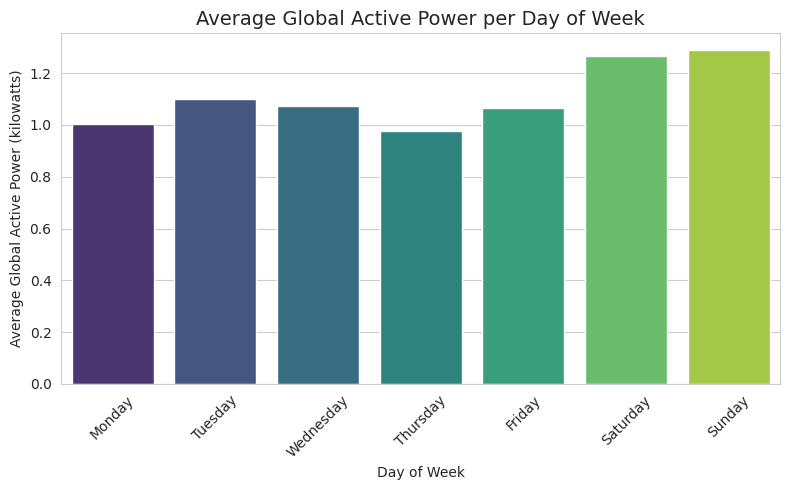

/tmp/ipython-input-1235812157.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_power_hour.index, y=avg_power_hour.values, palette='coolwarm')


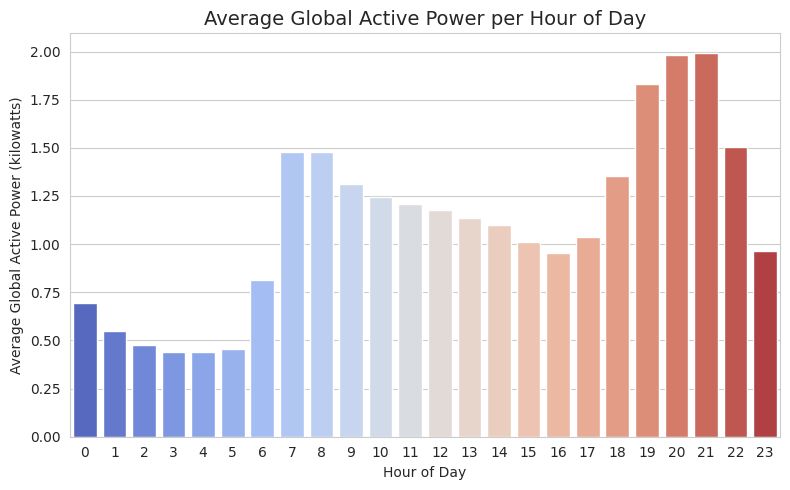

<Figure size 1000x600 with 0 Axes>

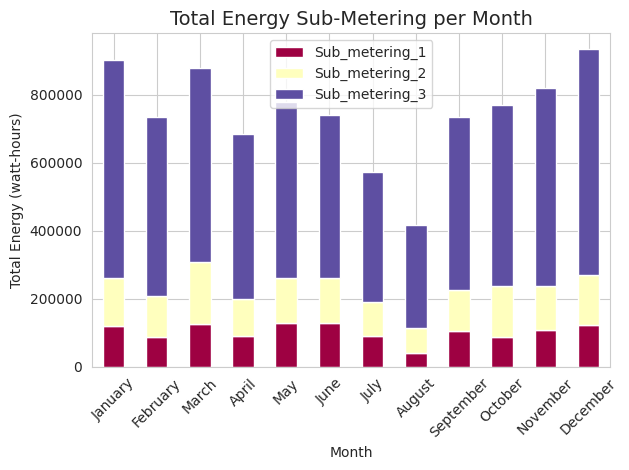

In [ ]:

# --- Step 1: Extract time features ---
df['DayOfWeek'] = df.index.day_name()
df['Hour'] = df.index.hour
df['Month'] = df.index.month_name()

# --- Step 2: Average Global Active Power by Day of Week ---
avg_power_day = df.groupby('DayOfWeek')['Global_active_power'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

plt.figure(figsize=(8,5))
sns.barplot(x=avg_power_day.index, y=avg_power_day.values, palette='viridis')
plt.title('Average Global Active Power per Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Average Global Active Power (kilowatts)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Step 3: Average Global Active Power by Hour of Day ---
avg_power_hour = df.groupby('Hour')['Global_active_power'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=avg_power_hour.index, y=avg_power_hour.values, palette='coolwarm')
plt.title('Average Global Active Power per Hour of Day', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Average Global Active Power (kilowatts)')
plt.tight_layout()
plt.show()

# --- Step 4: Total Energy Sub-Metering per Month ---
total_submetering = df.groupby('Month')[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].sum()
# order months properly
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
total_submetering = total_submetering.reindex(month_order).dropna(how='all')

plt.figure(figsize=(10,6))
total_submetering.plot(kind='bar', stacked=True, colormap='Spectral')
plt.title('Total Energy Sub-Metering per Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Energy (watt-hours)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


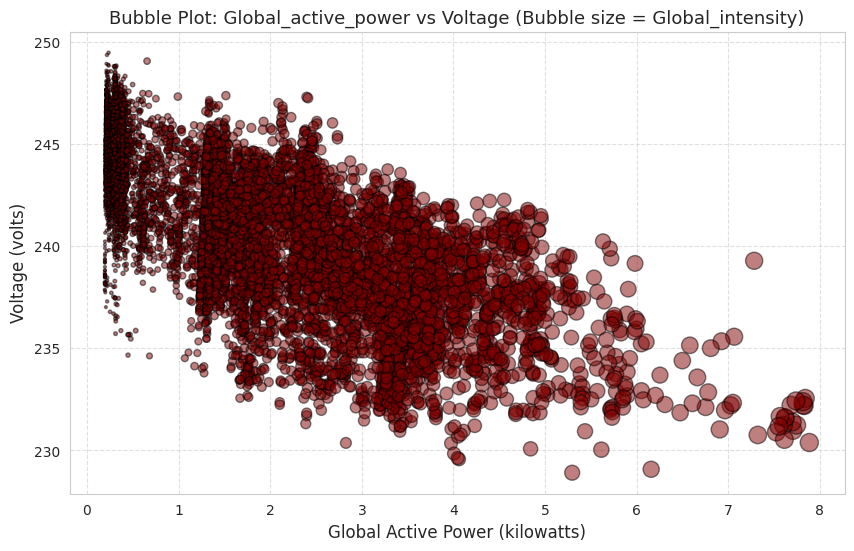

In [ ]:

plt.figure(figsize=(10, 6))
selected_df=df.iloc[0:10001]
plt.scatter(
    selected_df['Global_active_power'],
    selected_df['Voltage'],
    s=selected_df['Global_intensity'] * 5,  # bubble size (you can adjust multiplier)
    color='maroon',
    alpha=0.5,
    edgecolors='black'
)

plt.title('Bubble Plot: Global_active_power vs Voltage (Bubble size = Global_intensity)', fontsize=13)
plt.xlabel('Global Active Power (kilowatts)', fontsize=12)
plt.ylabel('Voltage (volts)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# IQR (Interquartile Range)

In [ ]:
numerical_features = [
    'Global_active_power', 'Global_reactive_power',
    'Voltage', 'Global_intensity',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]
outliers = {}

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find outliers
    outlier_values = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

    outliers[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Outliers': outlier_values.shape[0]
    }

# Display outlier information
pd.DataFrame(outliers).T


,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers
Global_active_power,0.28800,1.54600,1.25800,-1.59900,3.43300,55738.00000
Global_reactive_power,0.00000,0.18600,0.18600,-0.27900,0.46500,10274.00000
Voltage,237.96000,242.14000,4.18000,231.69000,248.41000,14144.00000
Global_intensity,1.20000,6.40000,5.20000,-6.60000,14.20000,58728.00000
Sub_metering_1,0.00000,0.00000,0.00000,0.00000,0.00000,85786.00000
Sub_metering_2,0.00000,1.00000,1.00000,-1.50000,2.50000,47179.00000
Sub_metering_3,0.00000,17.00000,17.00000,-25.50000,42.50000,0.00000


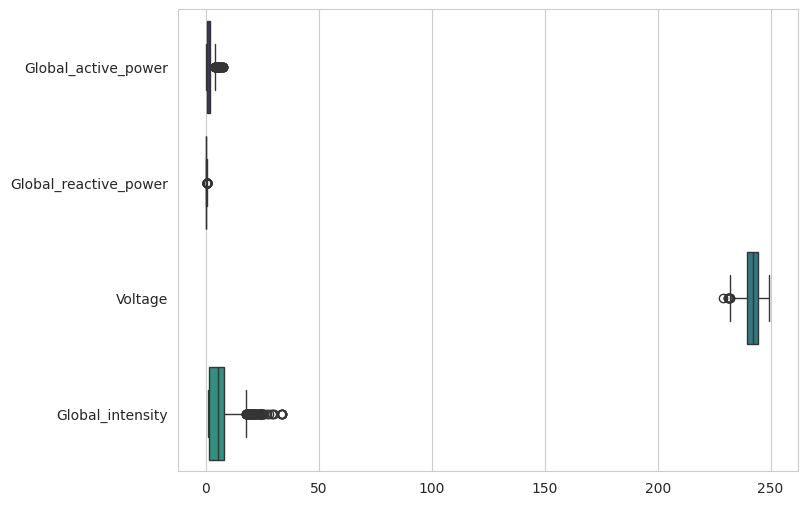

In [ ]:
plt.figure(figsize=(8,6))
selected_df=df.iloc[2000:6001]
features=['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']
sns.boxplot(data=selected_df[features], orient='h')
plt.show()

# Scaling Techniques

In [ ]:
numerical_features = [
    'Global_active_power', 'Global_reactive_power',
    'Voltage', 'Global_intensity',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df[numerical_features]),
                         columns=numerical_features)


standard_scaler = StandardScaler()
df_standard = pd.DataFrame(standard_scaler.fit_transform(df[numerical_features]),
                           columns=numerical_features)

# Categorical Encoding

In [ ]:
# Create a LabelEncoder object
le = LabelEncoder()

# Apply label encoding to the categorical columns
df['Month'] = le.fit_transform(df['Month'])
df['Hour'] = le.fit_transform(df['Hour'])
df['DayOfWeek'] = le.fit_transform(df['DayOfWeek'])

# Show the first few rows
print(df.head())


                     Global_active_power  Global_reactive_power   Voltage  \
Datetime                                                                    
2006-12-16 17:26:00              5.37400                0.49800 233.29000   
2006-12-16 17:27:00              5.38800                0.50200 233.74000   
2006-12-16 17:28:00              3.66600                0.52800 235.68000   
2006-12-16 17:29:00              3.52000                0.52200 235.02000   
2006-12-16 17:30:00              3.70200                0.52000 235.09000   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:26:00          23.00000         0.00000         2.00000   
2006-12-16 17:27:00          23.00000         0.00000         1.00000   
2006-12-16 17:28:00          15.80000         0.00000         1.00000   
2006-12-16 17:29:00          15.00000         0.00000         2.00000   
2006-12-16 17:30:00   

In [ ]:
# Perform one-hot encoding on Month, Hour, and Weekday
df_encoded = pd.get_dummies(df, columns=['Month', 'Hour', 'DayOfWeek'], drop_first=True)

# Show the first few rows
print(df_encoded.head())


                     Global_active_power  Global_reactive_power   Voltage  \
Datetime                                                                    
2006-12-16 17:26:00              5.37400                0.49800 233.29000   
2006-12-16 17:27:00              5.38800                0.50200 233.74000   
2006-12-16 17:28:00              3.66600                0.52800 235.68000   
2006-12-16 17:29:00              3.52000                0.52200 235.02000   
2006-12-16 17:30:00              3.70200                0.52000 235.09000   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:26:00          23.00000         0.00000         2.00000   
2006-12-16 17:27:00          23.00000         0.00000         1.00000   
2006-12-16 17:28:00          15.80000         0.00000         1.00000   
2006-12-16 17:29:00          15.00000         0.00000         2.00000   
2006-12-16 17:30:00   

In [ ]:
df.isnull().sum()

,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0
hour,0
day,0
month,0


# Heatmaps for Correlation Analysis

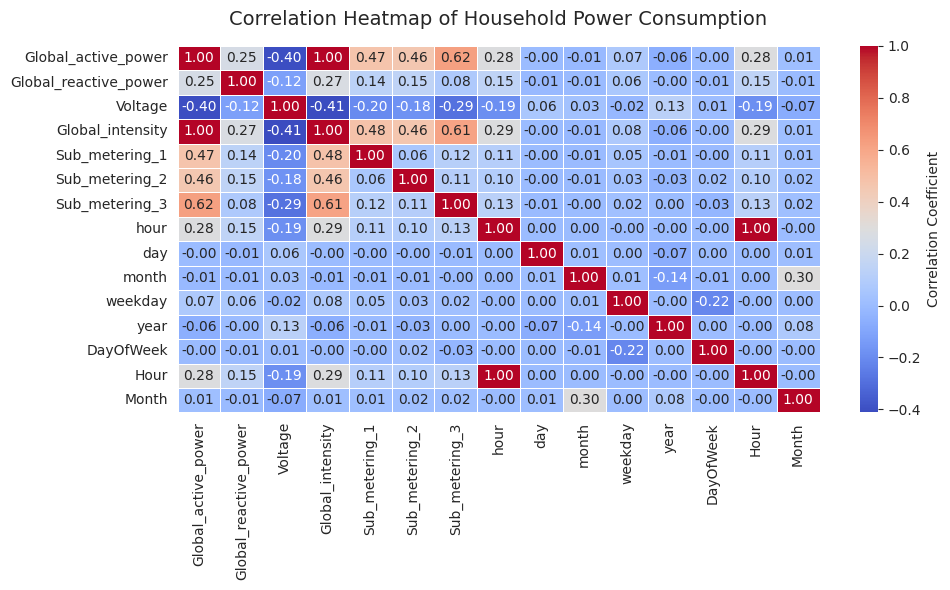

In [ ]:

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',   # you can try 'viridis', 'magma', or 'crest' too
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Correlation Heatmap of Household Power Consumption', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


# Grouping and Aggregation Analysis

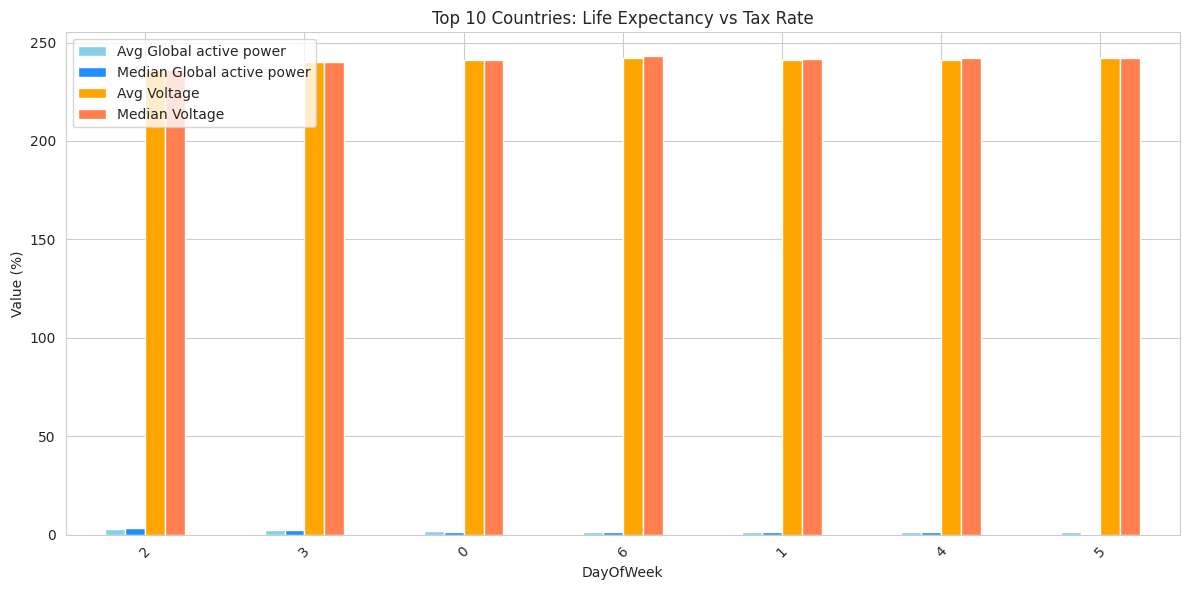

In [ ]:
select_df=df.iloc[0:9001]
selected_df = select_df.groupby('DayOfWeek').agg({
    'Global_active_power': ['mean', 'median'],
    'Voltage': ['mean', 'median']
}).sort_values(('Global_active_power', 'mean'), ascending=False).head(10)

# Rename columns
selected_df.columns = ['Avg Global active power', 'Median Global active power', 'Avg Voltage', 'Median Voltage']

# Plot
selected_df.plot(kind='bar', figsize=(12, 6), color=['skyblue', 'dodgerblue', 'orange', 'coral'])
plt.title('Top 10 Countries: Life Expectancy vs Tax Rate')
plt.ylabel('Value (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1042045 entries, 2006-12-16 17:26:00 to 2008-12-13 21:38:00
Data columns (total 17 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Global_active_power    1042045 non-null  float64
 1   Global_reactive_power  1042045 non-null  float64
 2   Voltage                1042045 non-null  float64
 3   Global_intensity       1042045 non-null  float64
 4   Sub_metering_1         1042045 non-null  float64
 5   Sub_metering_2         1042045 non-null  float64
 6   Sub_metering_3         1042045 non-null  float64
 7   hour                   1042045 non-null  int32  
 8   day                    1042045 non-null  int32  
 9   month                  1042045 non-null  int32  
 10  weekday                1042045 non-null  int32  
 11  year                   1042045 non-null  int32  
 12  lag_1                  1042045 non-null  object 
 13  lag_2                  1042045 non-null

In [ ]:
# Get all unique values in 'Hour' column
unique_days = df['weekday'].unique()
print("Unique values in Hour column:", unique_days)

Unique values in Hour column: [5 6 0 1 2 3 4]


# Check if required columns exists

In [ ]:
required_columns = [
    'day', 'Month', 'year', 'Hour', 'DayOfWeek', 'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

# Check if all required columns are present
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    print(f"Missing columns: {missing_columns}")
else:
    print("All required columns are present.")

All required columns are present.


In [ ]:
df.isnull().sum()

,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0
hour,0
day,0
month,0


# Prepare data

# Type 1: Predict overall power consumption at any given time

Predict total power usage using electrical parameters and time-based features.

In [ ]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day,month,weekday,year,lag_1,lag_2,DayOfWeek,Hour,Month
Datetime,,,,,,,,,,,,,,,,,
2006-12-16 17:26:00,5.37400,0.49800,233.29000,23.00000,0.00000,2.00000,17.00000,17,16,12,5,2006,5.36,4.216,2,17,2
2006-12-16 17:27:00,5.38800,0.50200,233.74000,23.00000,0.00000,1.00000,17.00000,17,16,12,5,2006,5.374,5.36,2,17,2
2006-12-16 17:28:00,3.66600,0.52800,235.68000,15.80000,0.00000,1.00000,17.00000,17,16,12,5,2006,5.388,5.374,2,17,2
2006-12-16 17:29:00,3.52000,0.52200,235.02000,15.00000,0.00000,2.00000,17.00000,17,16,12,5,2006,3.666,5.388,2,17,2
2006-12-16 17:30:00,3.70200,0.52000,235.09000,15.80000,0.00000,1.00000,17.00000,17,16,12,5,2006,3.52,3.666,2,17,2


In [ ]:
# Step 3: Prepare data
try:
    # Predictor variables (features)
    X = df[['Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'DayOfWeek', 'Month','Hour']]

    # Target variable
    y = df['Global_active_power']
except KeyError as e:
    print(f"Error accessing columns: {e}")
    exit(1)

print("Columns exist and data is ready for linear regression")


Columns exist and data is ready for linear regression


In [ ]:
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
except Exception as e:
    print(f"Train/test split failed: {e}")
    exit(1)

print("Train/test split successful")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

Train/test split successful
X_train shape: (833636, 8), X_test shape: (208409, 8)
y_train shape: (833636,), y_test shape: (208409,)


In [ ]:
df.isnull().sum()

,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0
hour,0
day,0
month,0


In [ ]:
try:
    model = LinearRegression()
    model.fit(X_train, y_train)
except Exception as e:
    print(f"Model training failed: {e}")
    exit(1)

print("Linear regression model trained successfully")

Linear regression model trained successfully


In [ ]:
try:
    # Predict on the test set
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R-squared (R²) Score: {r2:.4f}")
except Exception as e:
    print(f"Prediction or evaluation failed: {e}")
    exit(1)

Mean Squared Error (MSE): 0.0021
Mean Absolute Error (MAE): 0.0302
R-squared (R²) Score: 0.9984


In [ ]:
# Step 7: Predict new value
try:
    # Example new feature values: [Voltage, Global_intensity, Sub_metering_1, Sub_metering_2, Sub_metering_3, 'DayOfWeek', 'Month','Hour']
    new_value = [[240, 5, 1, 1, 2, 4, 10, 22]]  # Replace with real example values

    # Predict Global_active_power
    predicted_power = model.predict(new_value)

    print(f"Predicted Global Active Power for the given inputs: {predicted_power[0]:.4f} kW")
except Exception as e:
    print(f"Prediction for new value failed: {e}")
    exit(1)
# Example: calculate energy for 1 minute interval
predicted_energy_kwh = predicted_power[0] * (1/60)  # kW * hours
print(f"Predicted Energy for 1 minute: {predicted_energy_kwh:.4f} kWh")


Predicted Global Active Power for the given inputs: 1.1675 kW
Predicted Energy for 1 minute: 0.0195 kWh


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coef_df.sort_values('Coefficient', ascending=False))

In [ ]:
print(df[['Voltage', 'Global_intensity', 'Global_active_power']].describe())


            Voltage  Global_intensity  Global_active_power
count 1042045.00000     1042045.00000        1042045.00000
mean      239.95872           4.72648              1.11017
std         3.28552           4.76515              1.12994
min       223.49000           0.20000              0.07600
25%       237.96000           1.20000              0.28800
50%       240.21000           2.40000              0.55400
75%       242.14000           6.40000              1.54600
max       252.14000          46.40000             10.67000


# Type 2: Predict energy used by laundry-related devices.

Predict washing machine/laundry area power consumption patterns.

In [ ]:
# --- Feature Engineering ---
df['Hour_squared'] = df['Hour']**2
df['Hour_DayOfWeek'] = df['Hour'] * df['DayOfWeek']

# Lag features for time series (previous readings)
df['Prev_1'] = df['Sub_metering_3'].shift(1).fillna(0)
df['Prev_2'] = df['Sub_metering_3'].shift(2).fillna(0)

# Predictor variables (features)
X = df[['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity',
        'Sub_metering_1', 'Sub_metering_2', 'Hour', 'DayOfWeek', 'year', 'Month',
        'Hour_squared', 'Hour_DayOfWeek', 'Prev_1', 'Prev_2']]

# Target variable
y = df['Sub_metering_3']


In [ ]:
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
except Exception as e:
    print(f"Train/test split failed: {e}")
    exit(1)

print("Train/test split successful")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

Train/test split successful
X_train shape: (833636, 14), X_test shape: (208409, 14)
y_train shape: (833636,), y_test shape: (208409,)


In [ ]:
try:
    model = LinearRegression()
    model.fit(X_train, y_train)
except Exception as e:
    print(f"Model training failed: {e}")
    exit(1)

print("Linear regression model trained successfully")

Linear regression model trained successfully


In [ ]:
try:
    # Predict on the test set
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R-squared (R²) Score: {r2:.4f}")
except Exception as e:
    print(f"Prediction or evaluation failed: {e}")
    exit(1)

Mean Squared Error (MSE): 1.6547
Mean Absolute Error (MAE): 0.5646
R-squared (R²) Score: 0.9754


In [ ]:
# Step 7: Predict new value
try:
    # Example new feature values: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_3', 'Hour', 'Day_of_week', 'Month']
      new_value = [[1.8, 0.2, 241, 7, 0.6, 0.4, 19, 4, 2025, 10, 361, 76, 0.35, 0.25]]  # Replace with real example values

    # Predict Global_active_power
      predicted_power = model.predict(new_value)

      print(f"Predicted Global Active Power for the given inputs: {predicted_power[0]:.4f} kW")
except Exception as e:
    print(f"Prediction for new value failed: {e}")
    exit(1)

for i, p in enumerate(predicted_power):
    print(f"Scenario {i+1}: Predicted Sub_metering_3 = {p:.4f} kW, Energy for 1 min = {p/60:.4f} kWh")

Predicted Global Active Power for the given inputs: 1.7991 kW
Scenario 1: Predicted Sub_metering_3 = 1.7991 kW, Energy for 1 min = 0.0300 kWh


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
